# **Interpretability**

## 1. Selected Model

In [1]:
# Recreate final Random Forest model from Notebook 2

import os
os.makedirs('../reports/figures', exist_ok=True)
SAVE_PATH = '../reports/figures/'
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

df = pd.read_csv('../data/online_shoppers_intention.csv')

X = df.drop('Revenue', axis=1)
y = df['Revenue']

# Match Notebook 02's 3-way split: 70% train, 10% val, 20% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=2/3,
    stratify=y_temp,
    random_state=42
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

def engineer_features(X):
    """Apply same feature engineering as Notebook 02"""
    X = X.copy()
    X['total_duration'] = (X['Administrative_Duration'] +
                           X['Informational_Duration'] +
                           X['ProductRelated_Duration'])
    X['has_pagevalue'] = (X['PageValues'] > 0).astype(int)
    X['product_focus'] = X['ProductRelated_Duration'] / (X['total_duration'] + 1)
    X['pagevalue_exit_interaction'] = X['PageValues'] * (1 - X['ExitRates'])
    total_pages = X['Administrative'] + X['Informational'] + X['ProductRelated']
    X['engagement_rate'] = X['total_duration'] / (total_pages + 1)
    X['total_pages'] = X['Administrative'] + X['Informational'] + X['ProductRelated']
    return X

X_train = engineer_features(X_train)
X_val   = engineer_features(X_val)
X_test  = engineer_features(X_test)

numerical_features = [
    'PageValues', 'ExitRates', 'BounceRates', 'total_duration',
    'product_focus', 'engagement_rate', 'has_pagevalue',
    'pagevalue_exit_interaction', 'total_pages'
]

categorical_features = ['Month', 'VisitorType']
features_to_use = numerical_features + categorical_features

X_train_selected = X_train[features_to_use].copy()
X_val_selected   = X_val[features_to_use].copy()
X_test_selected  = X_test[features_to_use].copy()

X_train_encoded = pd.get_dummies(X_train_selected, columns=['Month', 'VisitorType'], drop_first=True)
X_val_encoded   = pd.get_dummies(X_val_selected,   columns=['Month', 'VisitorType'], drop_first=True)
X_test_encoded  = pd.get_dummies(X_test_selected,  columns=['Month', 'VisitorType'], drop_first=True)

scaler = StandardScaler()
scaler.fit(X_train_encoded[numerical_features])

X_train_scaled = X_train_encoded.copy()
X_val_scaled   = X_val_encoded.copy()
X_test_scaled  = X_test_encoded.copy()

X_train_scaled[numerical_features] = scaler.transform(X_train_encoded[numerical_features])
X_val_scaled[numerical_features]   = scaler.transform(X_val_encoded[numerical_features])
X_test_scaled[numerical_features]  = scaler.transform(X_test_encoded[numerical_features])

# Retrain on train + val combined, matching Notebook 02's final selected model
X_train_plus_val = pd.concat([X_train_scaled, X_val_scaled], axis=0)
y_train_plus_val = pd.concat([y_train, y_val], axis=0)

rf_model = RandomForestClassifier(
    max_depth=30,
    max_features='sqrt',
    min_samples_leaf=4,
    min_samples_split=10,
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_plus_val, y_train_plus_val)

y_pred_proba = rf_model.predict_proba(X_test_scaled)[:, 1]
y_pred_threshold = (y_pred_proba >= 0.319).astype(int)

from sklearn.metrics import confusion_matrix, roc_auc_score, fbeta_score, precision_score, recall_score

auc = roc_auc_score(y_test, y_pred_proba)
recall = recall_score(y_test, y_pred_threshold)
precision = precision_score(y_test, y_pred_threshold)
f2 = fbeta_score(y_test, y_pred_threshold, beta=2)

print(f"\nModel Performance (Threshold=0.319):")
print(f"AUC: {auc:.4f}")
print(f"Recall: {recall:.2f}")
print(f"Precision: {precision:.2f}")
print(f"F2 Score: {f2:.4f}")

cm = confusion_matrix(y_test, y_pred_threshold)
print(f"\nConfusion Matrix:")
print(cm)
print(f"Buyers caught: {cm[1,1]}/{int(y_test.sum())} ({cm[1,1]/y_test.sum():.1%})")

Train: (8631, 17), Val: (1233, 17), Test: (2466, 17)

Model Performance (Threshold=0.319):
AUC: 0.9297
Recall: 0.86
Precision: 0.53
F2 Score: 0.7613

Confusion Matrix:
[[1794  291]
 [  55  326]]
Buyers caught: 326/381 (85.6%)


## 2. SHAP Analysis

In [2]:
explainer = shap.TreeExplainer(rf_model)
shap_explanation = explainer(X_test_scaled)

shap_values_purchase = shap_explanation.values[:, :, 1]
base_value = shap_explanation.base_values[:, 1]

### 2.1 SHAP Feature Importance

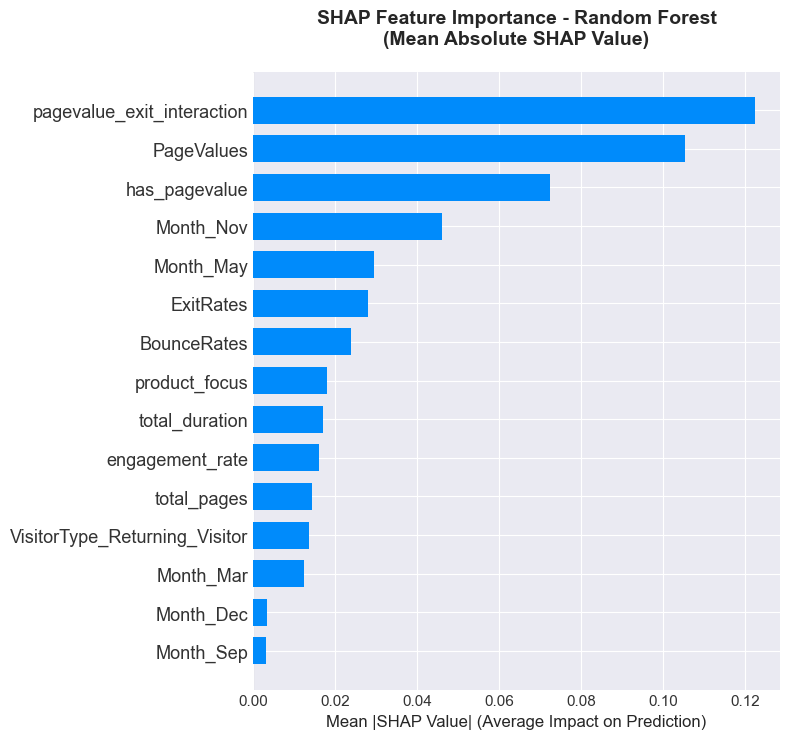

In [3]:
fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values_purchase, X_test_scaled, 
                  plot_type="bar", show=False, max_display=15)
plt.title('SHAP Feature Importance - Random Forest\n(Mean Absolute SHAP Value)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Mean |SHAP Value| (Average Impact on Prediction)', fontsize=12)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}shap_feature_importance_bar.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.2 SHAP Feature Impact Distribution

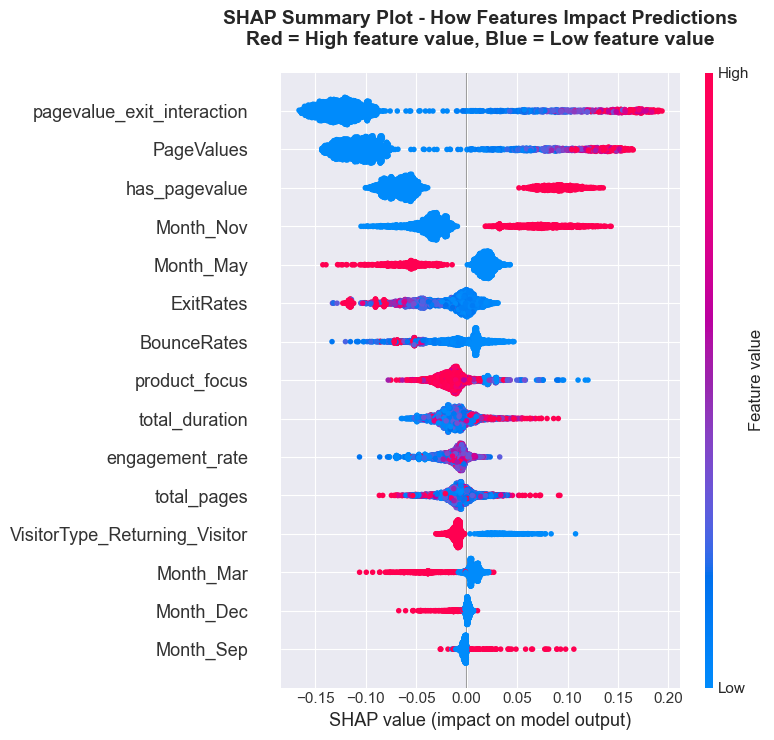

In [4]:
fig, ax = plt.subplots(figsize=(12, 10))
shap.summary_plot(shap_values_purchase, X_test_scaled, 
                  show=False, max_display=15)
plt.title('SHAP Summary Plot - How Features Impact Predictions\n' + 
          'Red = High feature value, Blue = Low feature value', 
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
plt.show()

### 2.3 Individual Prediction Case Analysis

2.3.1 Waterfall Plot: Confident Buyer


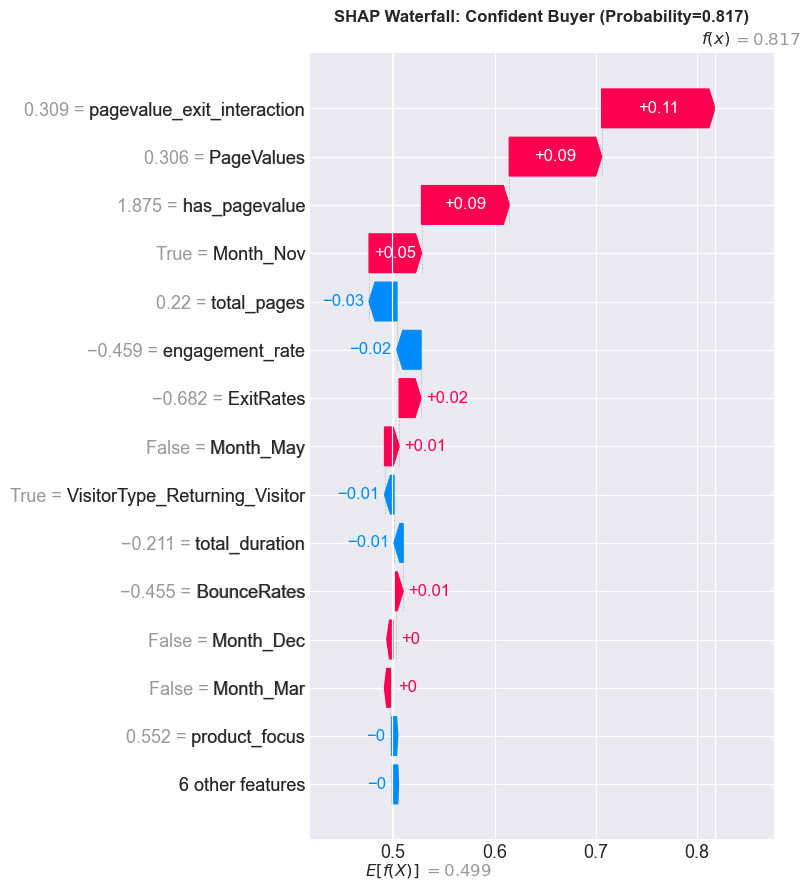

2.3.2 Waterfall Plot: Missed Buyer


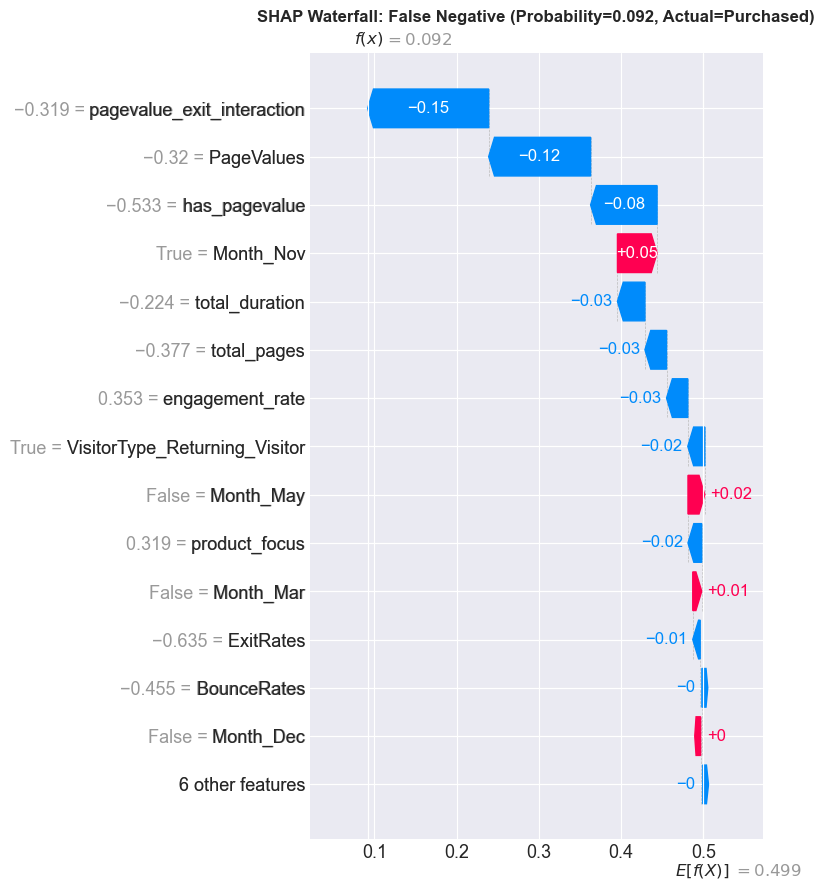

In [5]:
# High probability buyer who actually bought
high_prob_buyer = np.where((y_pred_proba > 0.8) & (y_test == 1))[0][0]

# False negative (predicted non-buyer, actually bought)
false_negative = np.where((y_pred_threshold == 0) & (y_test == 1))[0][0]

print("2.3.1 Waterfall Plot: Confident Buyer")

shap.plots.waterfall(shap_explanation[high_prob_buyer, :, 1], max_display=15, show=False)
plt.title(f'SHAP Waterfall: Confident Buyer (Probability={y_pred_proba[high_prob_buyer]:.3f})', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}shap_waterfall_confident_buyer.png', dpi=300, bbox_inches='tight')
plt.show()

print("2.3.2 Waterfall Plot: Missed Buyer")

shap.plots.waterfall(shap_explanation[false_negative, :, 1], max_display=15, show=False)
plt.title(f'SHAP Waterfall: False Negative (Probability={y_pred_proba[false_negative]:.3f}, Actual=Purchased)', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_PATH}shap_waterfall_false_negative.png', dpi=300, bbox_inches='tight')
plt.show()